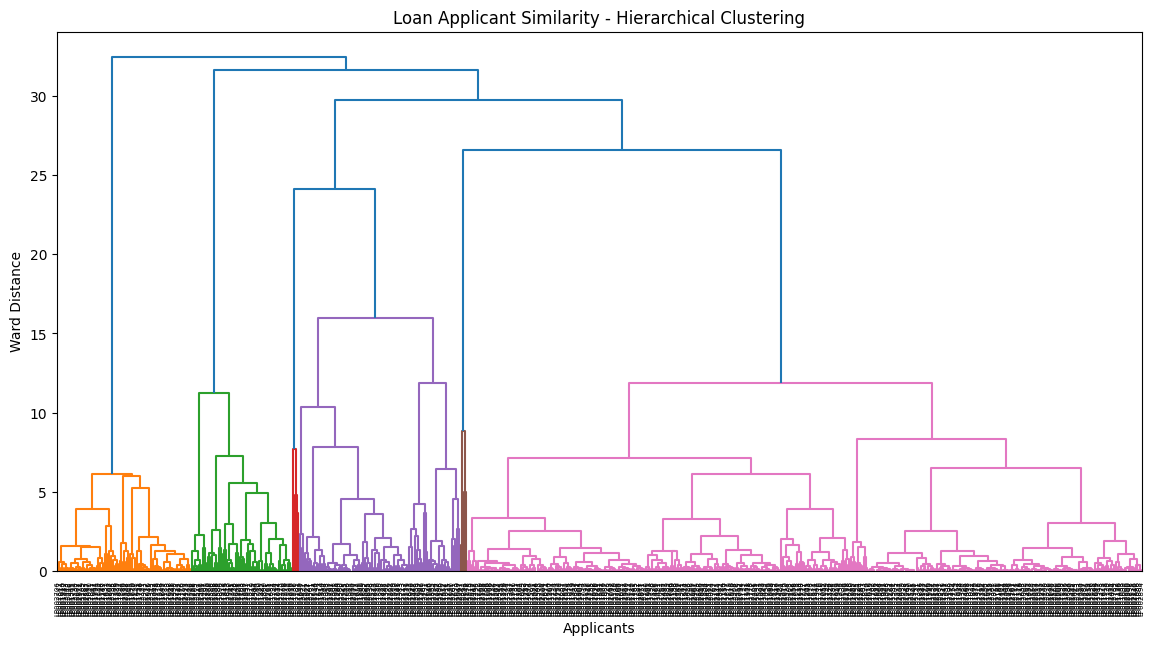

      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Read data
df = pd.read_csv("Loan-Approval-Prediction (1).csv")

# Select numerical features
x = df[[
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
]]

# Handle missing values by imputing column medians
x = x.fillna(x.median())

# Feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Create linkage matrix
z = linkage(x_scaled, method="ward")

# Create dendrogram
plt.figure(figsize=(14, 7))
dendrogram(z, labels=df["Loan_ID"].values)
plt.xlabel("Applicants")
plt.ylabel("Ward Distance")
plt.title("Loan Applicant Similarity - Hierarchical Clustering")
plt.show()

# Create Agglomerative Clustering model & predict clusters
model = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels = model.fit_predict(x_scaled)

# Add cluster column
df["Cluster"] = labels
print(df)